# Pipeline de medición de defectos en piezas cilíndricas

Este notebook implementa un pipeline completo para la **caracterización geométrica cuantitativa de defectos superficiales** (bollos, picos, hendiduras) en piezas de revolución escaneadas con sensor de rango 3D.

---

## 1. Adquisición y representación de datos

Cada muestra es un mapa de profundidad $Z(u, v)$ adquirido con una cámara de profundidad calibrada, donde $(u, v)$ son coordenadas de píxel y $Z$ es la coordenada métrica en mm. Las coordenadas métricas $X(u,v)$ e $Y(u,v)$ se obtienen del mismo fichero raw.

La resolución espacial $\delta$ (mm/px) se estima del rango métrico de los arrays $X$ e $Y$:

$$\delta = \frac{1}{2}\left(\frac{X_{\max} - X_{\min}}{W} + \frac{Y_{\max} - Y_{\min}}{H}\right)$$

Los píxeles sin medida válida ($Z = 0$ o $\pm\infty$) se excluyen de todos los cálculos.

---

## 2. Preprocesado: relleno y suavizado

Los huecos se rellenan con el **vecino más próximo**. Sobre el resultado se aplica un **filtro de mediana** de ventana $w_m \times w_m$ px para eliminar outliers sin destruir discontinuidades geométricas:

$$\tilde{Z}(u,v) = \operatorname{median}_{(i,j)\in\mathcal{N}_{w_m}(u,v)} Z(i,j)$$

---

## 3. Superficie nominal $Z_{\text{nom}}$ por interpolación de griddata

La profundidad nominal dentro del defecto se estima interpolando valores sanos del **anillo exterior** de anchura $d_{\text{ring}}$ mm con `scipy.interpolate.griddata` (triangulación de Delaunay + interpolación lineal baricéntrica):

$$Z_{\text{nom}}(u,v) = \sum_k \lambda_k(u,v)\, Z(u_k, v_k), \quad (u,v)\in\Omega_{\text{def}},\; (u_k,v_k)\in\Omega_{\text{ring}}$$

Esta estrategia respeta las **discontinuidades geométricas** entre caras a distintas alturas, donde los métodos paramétricos globales fallan.

La **desviación local** es:

$$Z_{\text{diff}}(u,v) = Z(u,v) - Z_{\text{nom}}(u,v)$$

- $Z_{\text{diff}} > 0$: material en exceso (bollo, pico).
- $Z_{\text{diff}} < 0$: material en defecto (hundimiento, raya).

---

## 4. Mezcla de Gaussianas 2D (multi-splat)

$Z_{\text{diff}}$ se modela como suma de $K$ Gaussianas 2D rotadas (**splats**):

$$\hat{Z}_{\text{diff}}(x,y) = \sum_{k=1}^{K} A_k \exp\!\left(-\frac{1}{2}\left[\frac{(x'-\mu_{x,k})^2}{\sigma_{x,k}^2} + \frac{(y'-\mu_{y,k})^2}{\sigma_{y,k}^2}\right]\right)$$

Cada splat tiene **6 parámetros**: $(A_k, \mu_{x,k}, \mu_{y,k}, \sigma_{x,k}, \sigma_{y,k}, \theta_k)$. El ajuste se realiza con `scipy.optimize.least_squares` (TRF), por separado para splats positivos y negativos.

**Selección de $K$** mediante **BIC**:

$$\text{BIC}(K) = \chi^2(K) + \lambda \cdot K \cdot \ln N, \qquad K^* = \arg\min_K \text{BIC}(K)$$

**Volúmenes** (mm³):

$$V_{\pm} = \delta^2 \sum_{(u,v)\in\Omega_{\text{def}}} \max\!\left(\pm Z_{\text{diff}}(u,v),\; 0\right)$$

---

## 5. Métricas geométricas por OBB (Oriented Bounding Box)

A partir de los centros de los splats activos se calcula la **OBB** por **PCA**:

1. Media ponderada: $\bar{\mu} = \frac{\sum_k |A_k| \mu_k}{\sum_k |A_k|}$.
2. Autovectores de la covarianza ponderada → ejes $\mathbf{e}_1$ (mayor) y $\mathbf{e}_2$ (menor).
3. $\ell = 2\max_k |\mathbf{e}_1^\top(\mu_k-\bar{\mu})|$; $w = 2\max_k |\mathbf{e}_2^\top(\mu_k-\bar{\mu})|$.

| Métrica | Símbolo | Unidad |
|---------|---------|--------|
| Largo | $\ell$ | mm |
| Ancho | $w$ | mm |
| Orientación | $\alpha$ | ° |
| Altura máxima (exceso) | $h_+$ | mm |
| Profundidad máxima | $h_-$ | mm |
| Volumen positivo / negativo / neto | $V_+$, $V_-$, $V_+-V_-$ | mm³ |

---

## 6. Tratamiento de defectos múltiples

Si la muestra tiene **más de un polígono**, cada uno se analiza de forma independiente. La carga XYZ y el preprocesado (pasos 1–2) se comparten y se ejecutan **una vez por muestra** (`prepare_sample`); los pasos 3–5 se ejecutan por separado para cada defecto (`analyze_polygon`).

In [1]:
%matplotlib inline
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

sys.path.insert(0, os.path.abspath("."))   # para importar gear_defect_pipeline
sys.path.insert(0, os.path.abspath(".."))  # para camera.raw

from gear_defect_pipeline import (
    analyze_defect,
    gauss_mixture,
    DEFAULT_PARAMS,
)

## Parámetros globales y descubrimiento de muestras

In [2]:
# ── Directorio raíz de las muestras ──────────────────────────────────────────
BASE_DIR = "../gears_defectos_xyz_etiquetados"

# ── Parámetros del pipeline (se pueden sobreescribir por muestra) ─────────────
PIPELINE_PARAMS = dict(
    erosion_px    = 5,
    med_win       = 15,
    sg_win_px     = 21,
    thr_tapa_deg  = 30.0,
    n_wall_bins   = 16,
    ring_mm       = 8.0,
    search_mm     = 10.0,
    k_max         = 12,
    win_defect_mm = 4.0,
    lambda_pen    = 5.0,
    thr_frac      = 0.05,
    n_splat_sub   = 2000,
)

# ── Descubrir todas las muestras disponibles ─────────────────────────────────
def discover_samples(base_dir: str) -> list[str]:
    """Devuelve lista de nombres de muestra que tienen save_xyz y rgb_seg."""
    samples = []
    for name in sorted(os.listdir(base_dir)):
        entities = os.path.join(base_dir, name, "debug", "entities")
        xyz_ok  = os.path.isfile(os.path.join(entities, "save_xyz", f"{name}_save_xyz.raw"))
        seg_ok  = os.path.isfile(os.path.join(entities, "rgb_seg",  f"{name}_rgb_seg.txt"))
        if xyz_ok and seg_ok:
            samples.append(name)
    return samples

SAMPLES = discover_samples(BASE_DIR)
print(f"Muestras encontradas: {len(SAMPLES)}")
for s in SAMPLES:
    print(f"  {s}")

Muestras encontradas: 5
  061125_144524_P17231_S4_7762
  061125_144533_P17234_S3_7762
  151225_155112_P44473_S2_7761
  151225_160136_P44512_S2_7761
  311025_113230_P11447_S7_7762


## Análisis en batch

In [3]:
results_all = {}   # sample -> lista de dicts, uno por defecto
errors      = {}   # sample -> excepción si falló

for i, sample in enumerate(SAMPLES):
    print(f"\n[{i+1}/{len(SAMPLES)}] {sample}")
    try:
        defs = analyze_defect(sample, BASE_DIR, verbose=True, **PIPELINE_PARAMS)
        results_all[sample] = defs
        for d in defs:
            idx = d['defect_idx']
            print(f"  ✓  defecto {idx}  "
                  f"largo={d['largo']:.2f}mm  ancho={d['ancho']:.2f}mm  "
                  f"V+={d['V_pos']:.3f}  V-={d['V_neg']:.3f}  std={d['Z_diff_std']:.3f}mm")
    except Exception as exc:
        errors[sample] = exc
        print(f"  ✗  ERROR: {exc}")

print(f"\nCompletadas: {len(results_all)}/{len(SAMPLES)}  |  Errores: {len(errors)}")



[1/5] 061125_144524_P17231_S4_7762

── Defecto 1/1 ──
[061125_144524_P17231_S4_7762[0]] Multi-splat POSITIVO …
  K=1: V=0.2339 mm³  nfev=12  t=6ms  BIC=2.0857
  K=2: V=0.3142 mm³  nfev=6  t=11ms  BIC=2.1170
  K=3: V=0.3861 mm³  nfev=5  t=16ms  BIC=2.1691
  → early stop en K=3 (BIC no mejora 2 iteraciones)
[061125_144524_P17231_S4_7762[0]] Multi-splat NEGATIVO …
  K=1: V=4.4132 mm³  nfev=11  t=5ms  BIC=247.6405
  K=2: V=8.1455 mm³  nfev=7  t=10ms  BIC=189.0808
  K=3: V=14.1848 mm³  nfev=9  t=20ms  BIC=159.6252
  K=4: V=14.9500 mm³  nfev=11  t=32ms  BIC=123.2235
  K=5: V=17.2743 mm³  nfev=8  t=43ms  BIC=101.9895
  K=6: V=20.7934 mm³  nfev=19  t=91ms  BIC=94.4101
  K=7: V=18.9700 mm³  nfev=12  t=127ms  BIC=65.7876
  K=8: V=18.5168 mm³  nfev=10  t=165ms  BIC=58.7665
  K=9: V=19.7298 mm³  nfev=8  t=195ms  BIC=61.9461
  K=10: V=19.6842 mm³  nfev=7  t=224ms  BIC=66.5600
  → early stop en K=10 (BIC no mejora 2 iteraciones)
[061125_144524_P17231_S4_7762[0]] Completado en 0.7s
  ✓  defecto 0  l

## Tabla de métricas

In [4]:
METRIC_COLS = [
    'sample', 'defect_idx', 'pix_mm', 'n_defect_px',
    'Z_diff_std', 'Z_diff_min', 'Z_diff_max',
    'K_best_pos', 'V_pos', 'K_best_neg', 'V_neg', 'V_net',
    'largo', 'ancho', 'ang_deg', 'h_max', 'h_min',
    't_total',
]

rows = []
for sample, defs in results_all.items():
    for d in defs:
        rows.append({col: d.get(col) for col in METRIC_COLS})

df = pd.DataFrame(rows).set_index(['sample', 'defect_idx'])

float_cols = ['pix_mm', 'Z_diff_std', 'Z_diff_min', 'Z_diff_max',
               'V_pos', 'V_neg', 'V_net', 'largo', 'ancho', 'ang_deg', 'h_max', 'h_min']
df_display = df.copy()
df_display[float_cols] = df_display[float_cols].round(4)

display(df_display)

out_csv = os.path.join(".", "batch_results.csv")
df.to_csv(out_csv, float_format='%.5f')
print(f"Guardado en {out_csv}")


pix_mm  n_defect_px  Z_diff_std  \
sample                       defect_idx                                    
061125_144524_P17231_S4_7762 0           0.1095         4347      0.2179   
061125_144533_P17234_S3_7762 0           0.1069         5802      0.3077   
                             1           0.1069          840      0.0773   
151225_155112_P44473_S2_7761 0           0.1252         3699      0.1300   
151225_160136_P44512_S2_7761 0           0.1269         3987      0.2516   
311025_113230_P11447_S7_7762 0           0.1046         9074      0.4925   
                             1           0.1046         2231      0.2871   
                             2           0.1046         2659      0.2703   

                                         Z_diff_min  Z_diff_max  K_best_pos  \
sample                       defect_idx                                       
061125_144524_P17231_S4_7762 0              -0.8044      0.2104           1   
061125_144533_P17234_S3_7762 0              -0.6680      1.0781           7   
                             1              -0.5462      0.1993           1   
151225_155112_P44473_S2_7761 0              -0.5371      0.2212           1   
151225_160136_P44512_S2_7761 0              -0.4504      0.6024           5   
311025_113230_P11447_S7_7762 0              -1.9676      0.9131           2   
                             1              -1.0838      0.3398           2   
                             2              -1.1455      1.0011           3   

                                           V_pos  K_best_neg    V_neg  \
sample                       defect_idx                                 
061125_144524_P17231_S4_7762 0            0.2339           8  18.5168   
061125_144533_P17234_S3_7762 0           22.9901           1   1.1818   
                             1            0.2338           1   0.2715   
151225_155112_P44473_S2_7761 0            0.0304          11  11.0017   
151225_160136_P44512_S2_7761 0           10.7813           1   4.2785   
311025_113230_P11447_S7_7762 0            5.3833          12  42.4858   
                             1            0.4848          10   8.3404   
                             2            0.8901           8   7.9499   

                                           V_net    largo   ancho   ang_deg  \
sample                       defect_idx                                       
061125_144524_P17231_S4_7762 0          -18.2828  16.8766  5.3590  151.8207   
061125_144533_P17234_S3_7762 0           21.8083  10.7580  8.8914  146.2719   
                             1           -0.0377   6.2725  2.2126  156.2968   
151225_155112_P44473_S2_7761 0          -10.9714  35.9227  2.3270  179.7980   
151225_160136_P44512_S2_7761 0            6.5029  10.4533  8.7939   87.6383   
311025_113230_P11447_S7_7762 0          -37.1026  39.4497  3.9307  122.9567   
                             1           -7.8556  12.7637  3.0418  179.6530   
                             2           -7.0598  11.5443  2.9531  174.2225   

                                          h_max   h_min   t_total  
sample                       defect_idx                            
061125_144524_P17231_S4_7762 0           0.0316  0.7141  0.696539  
061125_144533_P17234_S3_7762 0           0.9361  0.2970  0.814449  
                             1           0.0420  0.1823  0.476865  
151225_155112_P44473_S2_7761 0           0.0059  0.4455  1.027138  
151225_160136_P44512_S2_7761 0           0.6080  0.3994  0.512796  
311025_113230_P11447_S7_7762 0           0.3454  1.8759  1.712645  
                             1           0.1613  1.0365  0.885859  
                             2           0.9453  0.7619  1.110556

Guardado en ./batch_results.csv


## Visualización comparativa

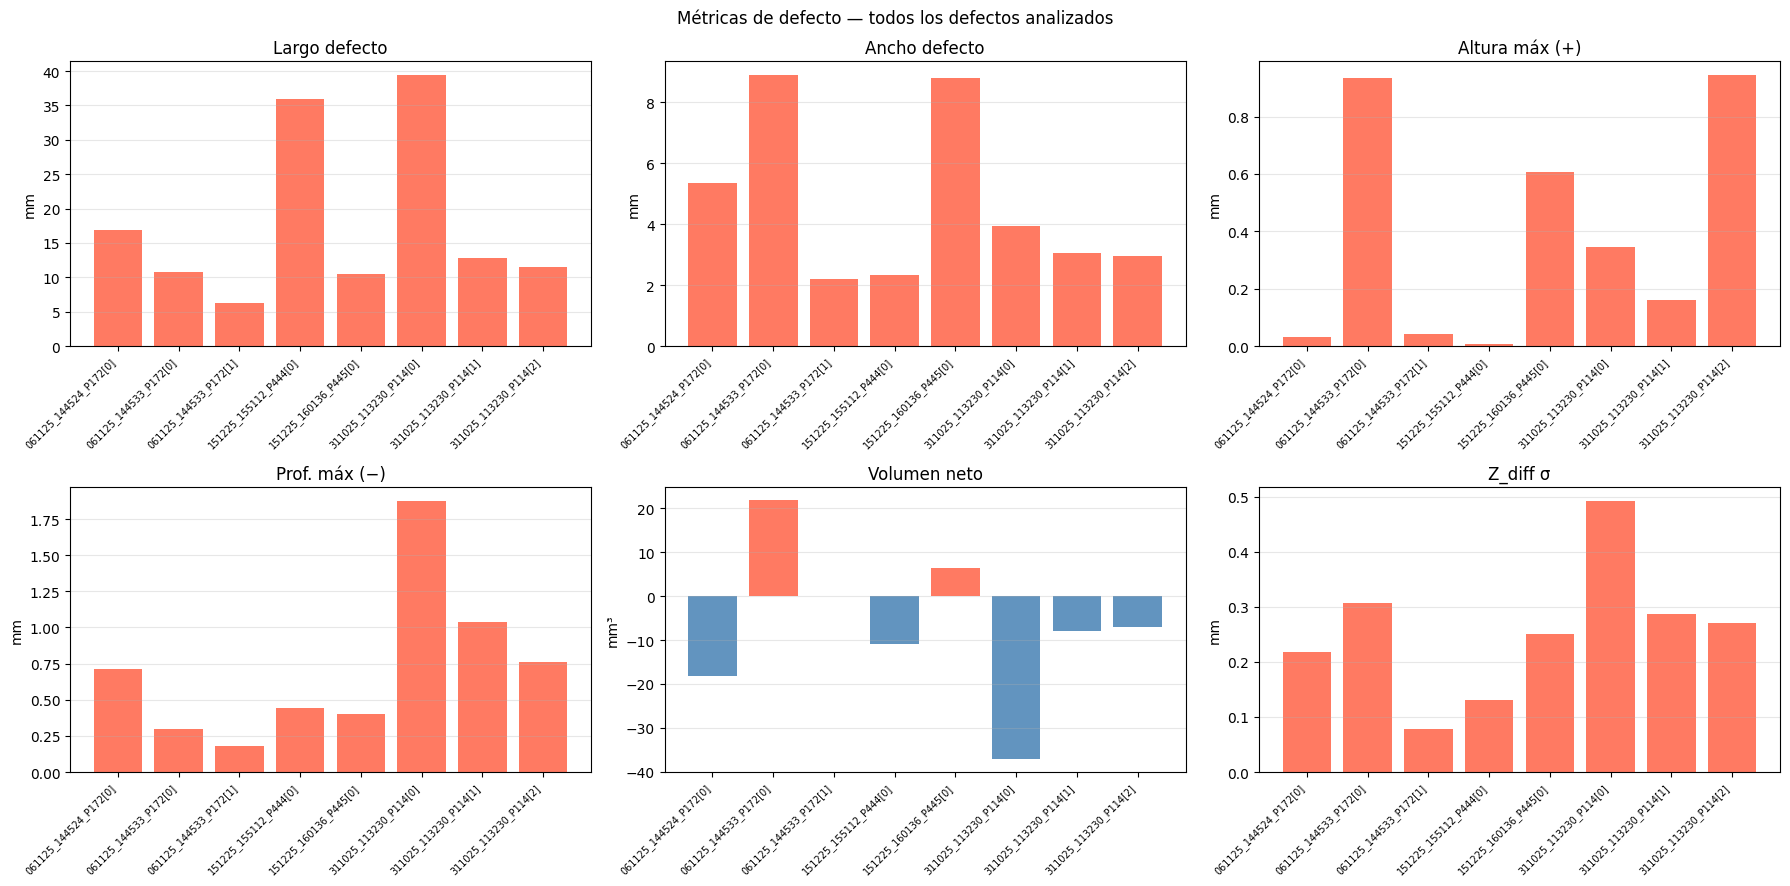

In [5]:
if len(df) == 0:
    print("Sin resultados para visualizar.")
else:
    df_flat = df.reset_index()
    df_flat['label'] = df_flat.apply(
        lambda r: f"{r['sample'][:18]}[{r['defect_idx']}]", axis=1)
    labels_short = df_flat['label'].tolist()
    x = np.arange(len(labels_short))

    fig, axes = plt.subplots(2, 3, figsize=(18, 9))

    def bar(ax, col, title, unit=''):
        vals = df_flat[col].values.astype(float)
        colors = ['tomato' if v > 0 else 'steelblue' for v in vals]
        ax.bar(x, vals, color=colors, alpha=0.85)
        ax.set_xticks(x); ax.set_xticklabels(labels_short, rotation=45, ha='right', fontsize=7)
        ax.set_title(title); ax.set_ylabel(unit); ax.grid(axis='y', alpha=0.3)

    bar(axes[0, 0], 'largo',     'Largo defecto',  'mm')
    bar(axes[0, 1], 'ancho',     'Ancho defecto',  'mm')
    bar(axes[0, 2], 'h_max',     'Altura máx (+)', 'mm')
    bar(axes[1, 0], 'h_min',     'Prof. máx (−)',  'mm')
    bar(axes[1, 1], 'V_net',     'Volumen neto',   'mm³')
    bar(axes[1, 2], 'Z_diff_std','Z_diff σ',       'mm')

    plt.suptitle('Métricas de defecto — todos los defectos analizados', fontsize=12)
    plt.tight_layout()
    plt.show()


## Galería: Z_diff + OBB para todas las muestras analizadas

Para cada muestra se muestra: imagen Z completa de la pieza | Z_diff + splats + OBB.


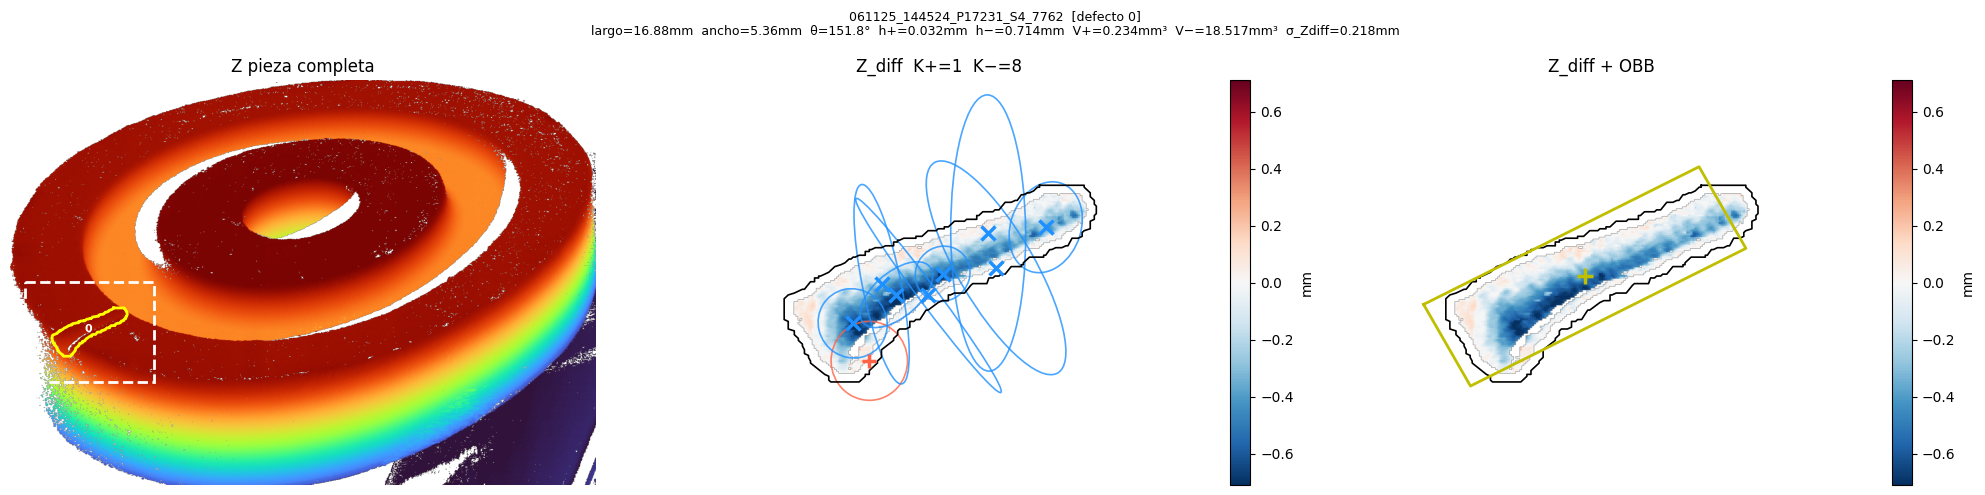

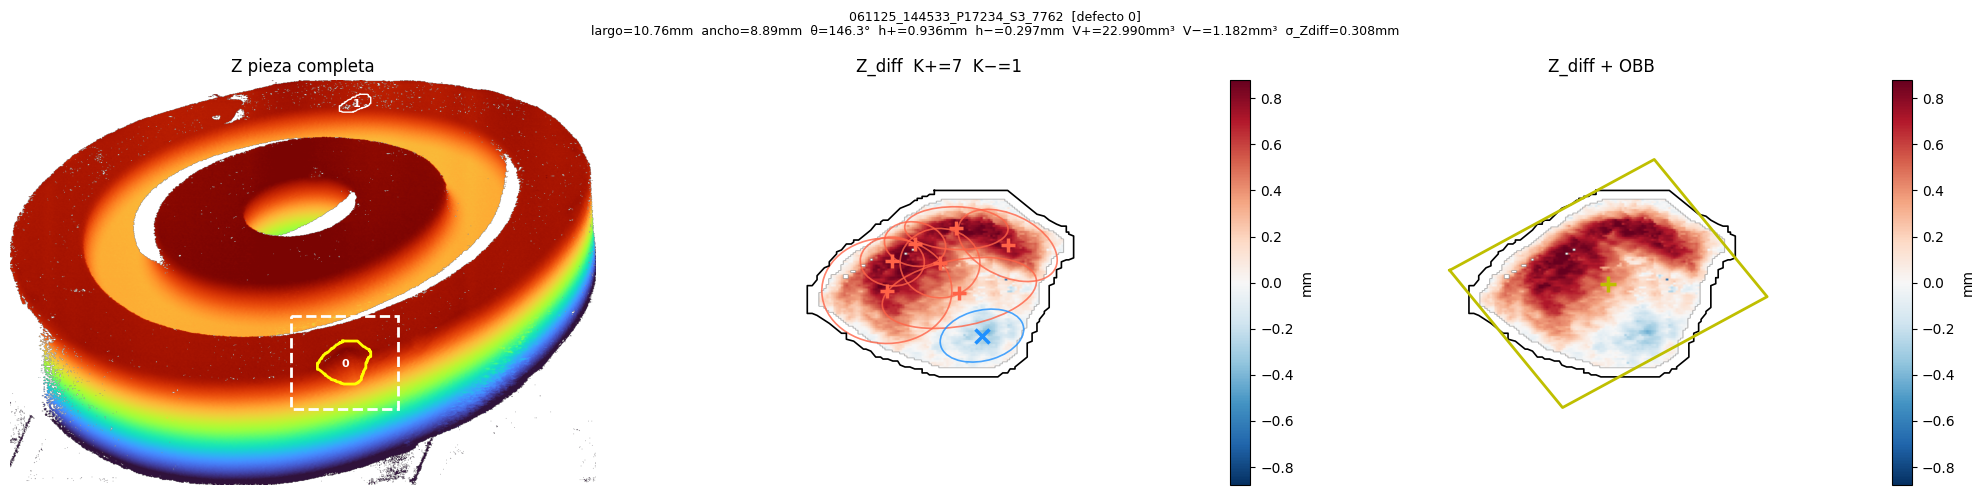

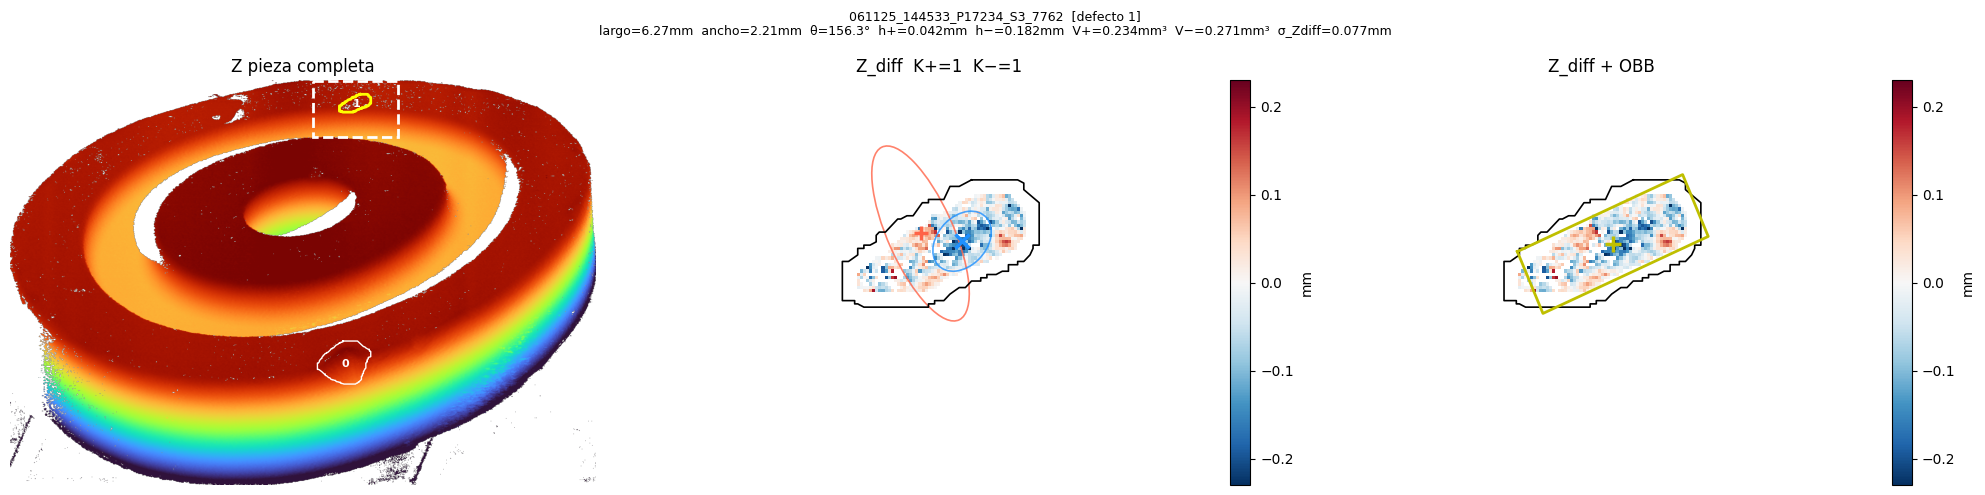

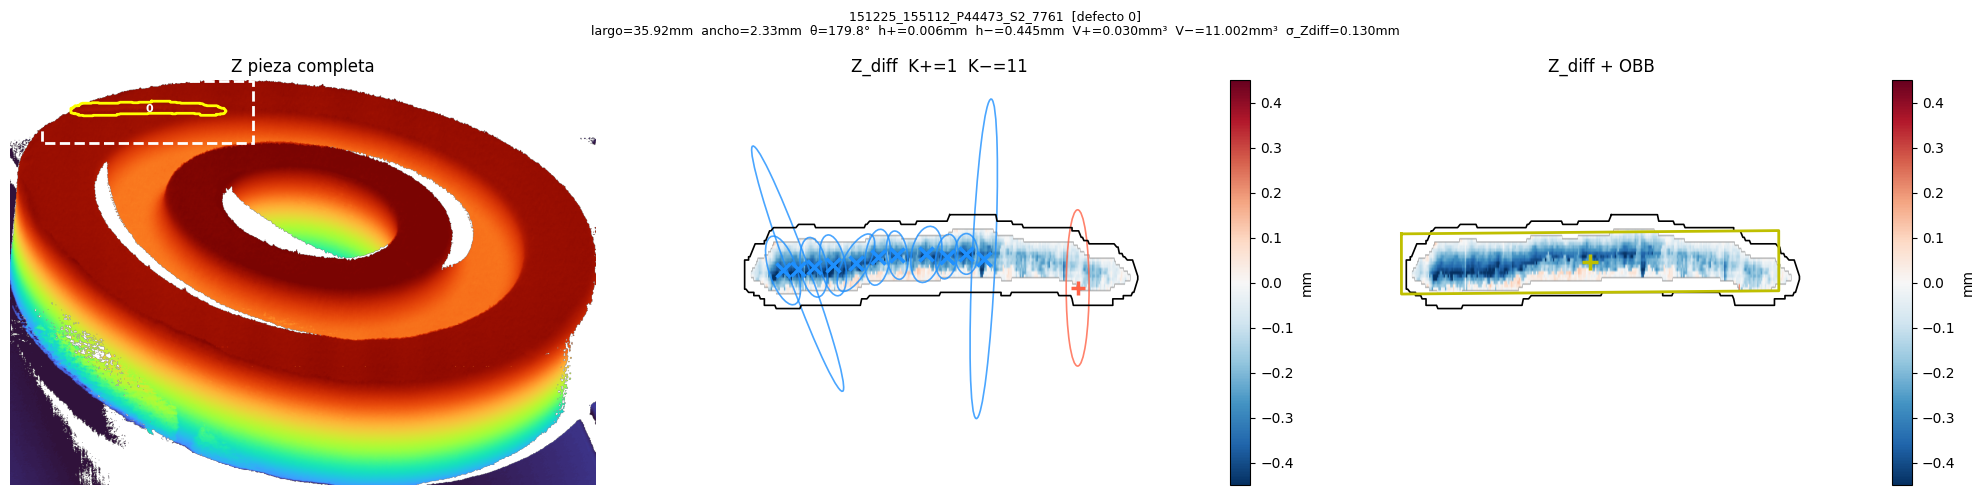

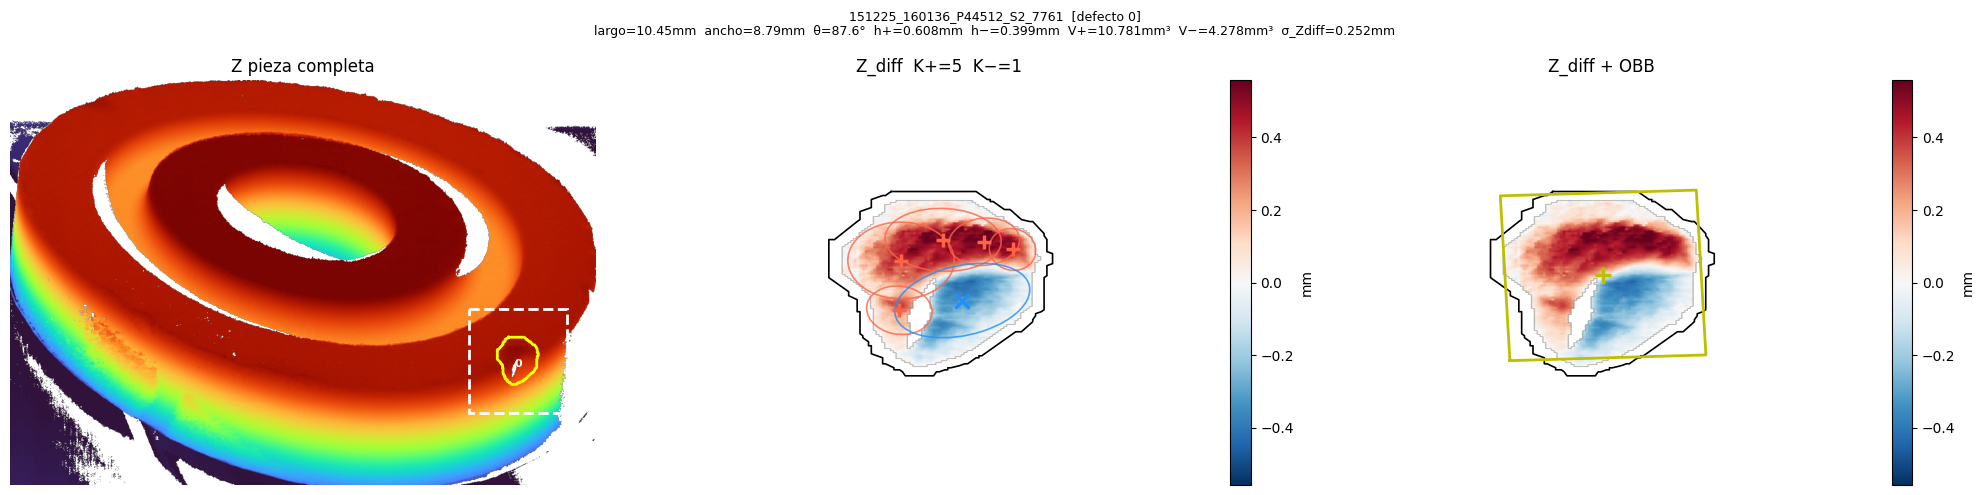

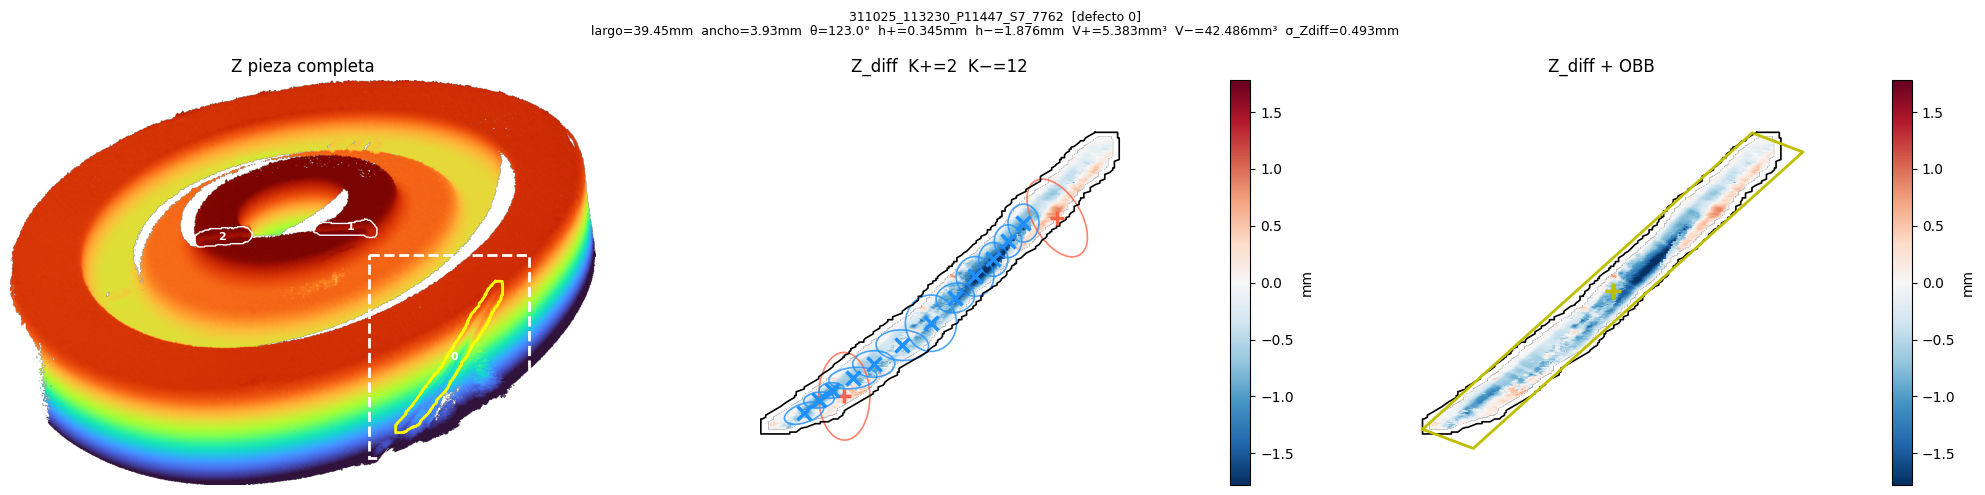

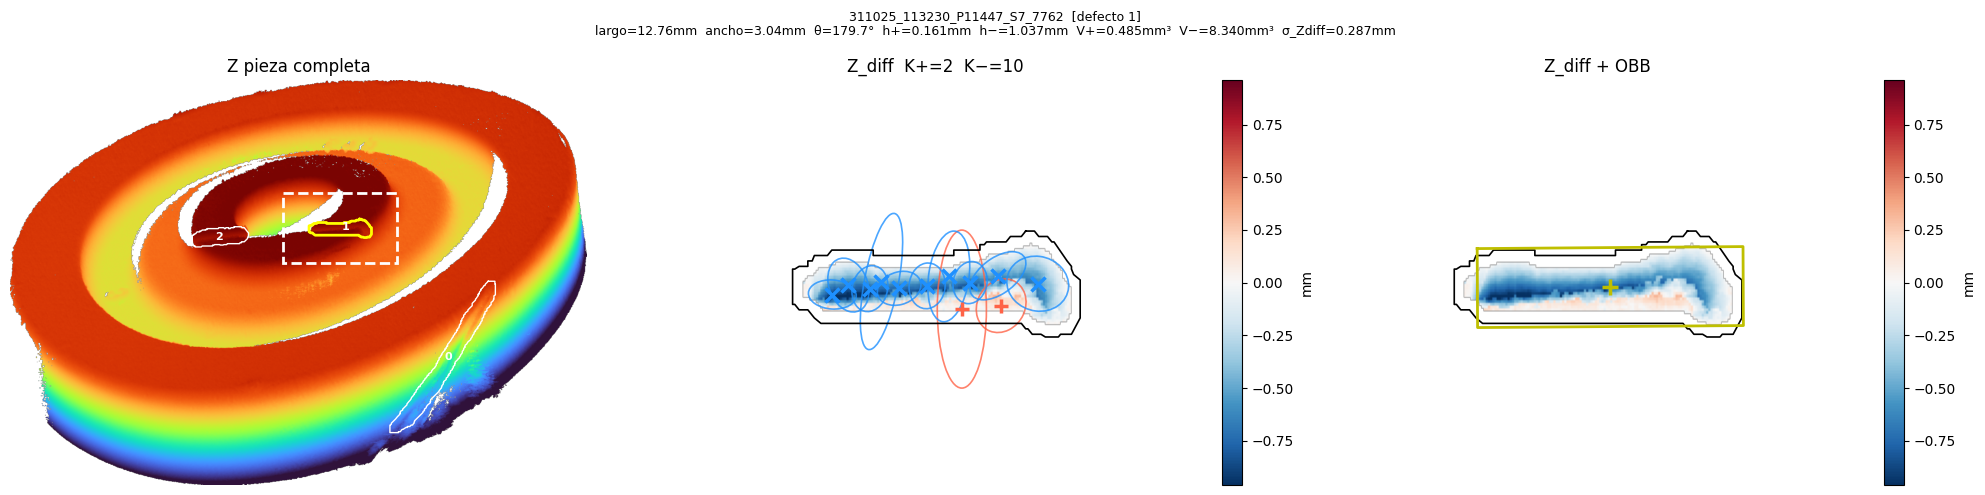

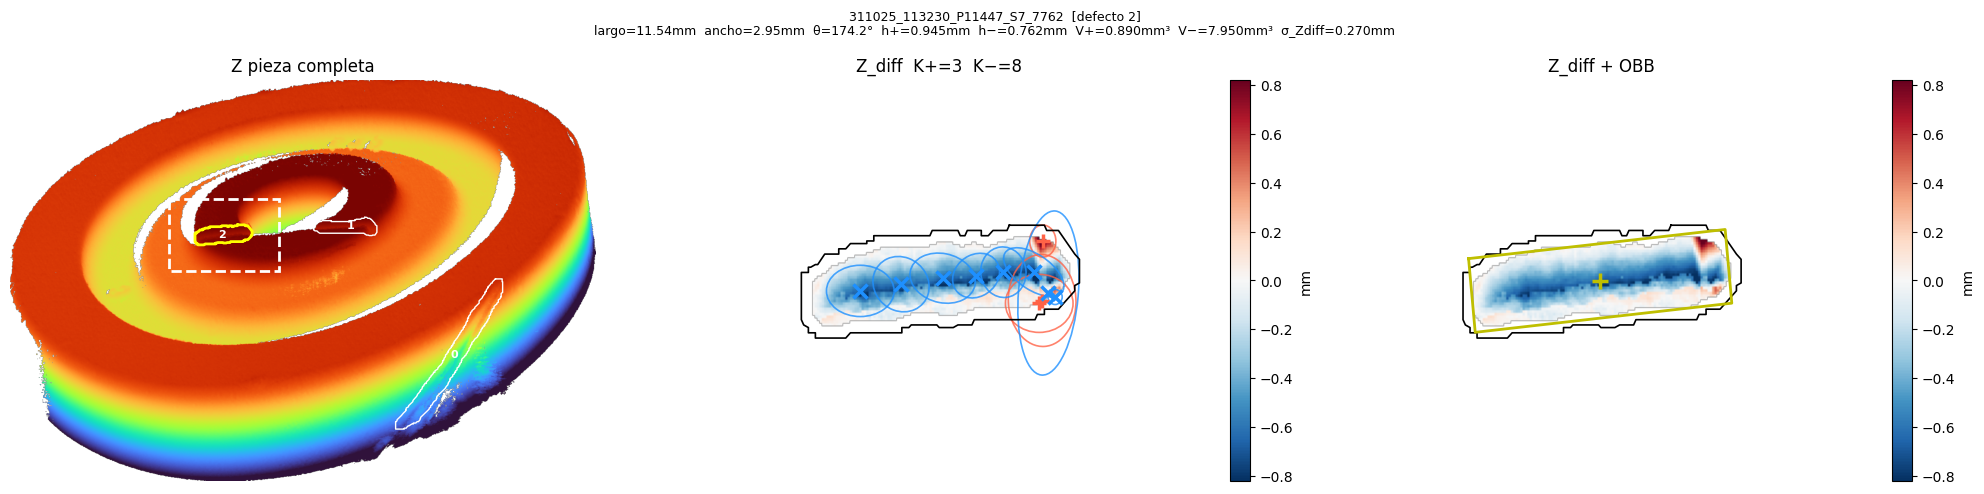

In [6]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
import camera.raw as raw
from gear_defect_pipeline import load_xyz

# Cachés de Z_full para no recargar la misma muestra varias veces
_z_full_cache = {}

def get_z_full(sample):
    if sample in _z_full_cache:
        return _z_full_cache[sample]
    entities = os.path.join(BASE_DIR, sample, "debug", "entities")
    xyz_path = os.path.join(entities, "save_xyz", f"{sample}_save_xyz.raw")
    xyz_full = raw.read_img_raw(xyz_path)
    Z_full = xyz_full[:, :, 2].astype(float)
    Z_full[~(np.isfinite(Z_full) & (Z_full != 0))] = np.nan
    _z_full_cache[sample] = Z_full
    return Z_full


for sample, defs in results_all.items():
    Z_full = get_z_full(sample)
    vmin_z = float(np.nanpercentile(Z_full, 2))
    vmax_z = float(np.nanpercentile(Z_full, 98))

    # Todos los polígonos de esta muestra (para superponerlos en el panel global)
    all_polys = [d['polygon'] for d in defs]

    for res in defs:
        idx   = res['defect_idx']
        pix   = res['pix_mm']
        Zd    = res['Z_diff']
        p_pos = res['params_pos']
        p_neg = res['params_neg']
        obb   = res['obb']
        poly  = res['polygon']          # polígono de ESTE defecto
        rows_d = res['rows_def_s']
        cols_d = res['cols_def_s']

        # Recorte alrededor de este defecto
        margin = 60
        r0v = max(0, rows_d.min() - margin);  r1v = min(Zd.shape[0], rows_d.max() + margin)
        c0v = max(0, cols_d.min() - margin);  c1v = min(Zd.shape[1], cols_d.max() + margin)
        Zd_cr = Zd[r0v:r1v, c0v:c1v]

        finite_vals = Zd[np.isfinite(Zd)]
        vmax_d = float(np.nanpercentile(np.abs(finite_vals), 99)) if len(finite_vals) else 1.0

        fig, axes = plt.subplots(1, 3, figsize=(20, 5))

        # ── Panel 1: Z pieza completa con recuadros ───────────────────────────
        axes[0].imshow(Z_full, cmap='turbo', aspect='auto', vmin=vmin_z, vmax=vmax_z)
        # Recuadro del defecto actual (blanco sólido)
        from matplotlib.patches import Rectangle
        rect = Rectangle((c0v, r0v), c1v - c0v, r1v - r0v,
                         linewidth=2, edgecolor='white', facecolor='none', linestyle='--')
        axes[0].add_patch(rect)
        # Todos los polígonos de la muestra superpuestos
        for j, pts in enumerate(all_polys):
            closed = np.vstack([pts, pts[0]])
            color = 'yellow' if j == idx else 'white'
            lw    = 2.0      if j == idx else 1.0
            axes[0].plot(closed[:, 0], closed[:, 1], '-', color=color, lw=lw)
            cy_label = pts[:, 1].mean();  cx_label = pts[:, 0].mean()
            axes[0].text(cx_label, cy_label, str(j), color='white', fontsize=8,
                         ha='center', va='center', fontweight='bold')
        axes[0].set_title('Z pieza completa')
        axes[0].axis('off')

        # ── Panel 2: Z_diff + splats ──────────────────────────────────────────
        im1 = axes[1].imshow(Zd_cr, cmap='RdBu_r', aspect='auto', vmin=-vmax_d, vmax=vmax_d)
        plt.colorbar(im1, ax=axes[1], label='mm', fraction=0.046, pad=0.04)
        closed_l = np.vstack([poly, poly[0]]) - np.array([c0v, r0v])
        axes[1].plot(closed_l[:, 0], closed_l[:, 1], 'k-', lw=1.2)
        for j in range(len(p_pos) // 6):
            cx = p_pos[6*j+1]/pix - c0v;  cy = p_pos[6*j+2]/pix - r0v
            sx = p_pos[6*j+3]/pix;        sy = p_pos[6*j+4]/pix
            axes[1].plot(cx, cy, '+', color='tomato', ms=10, mew=2.5)
            axes[1].add_patch(mpatches.Ellipse((cx, cy), 4*sx, 4*sy,
                angle=np.degrees(p_pos[6*j+5]), fill=False, edgecolor='tomato', lw=1.2, alpha=0.8))
        for j in range(len(p_neg) // 6):
            cx = p_neg[6*j+1]/pix - c0v;  cy = p_neg[6*j+2]/pix - r0v
            sx = p_neg[6*j+3]/pix;        sy = p_neg[6*j+4]/pix
            axes[1].plot(cx, cy, 'x', color='dodgerblue', ms=10, mew=2.5)
            axes[1].add_patch(mpatches.Ellipse((cx, cy), 4*sx, 4*sy,
                angle=np.degrees(p_neg[6*j+5]), fill=False, edgecolor='dodgerblue', lw=1.2, alpha=0.8))
        axes[1].set_title(f'Z_diff  K+={res["K_best_pos"]}  K−={res["K_best_neg"]}')
        axes[1].axis('off')

        # ── Panel 3: Z_diff + OBB ─────────────────────────────────────────────
        im2 = axes[2].imshow(Zd_cr, cmap='RdBu_r', aspect='auto', vmin=-vmax_d, vmax=vmax_d)
        plt.colorbar(im2, ax=axes[2], label='mm', fraction=0.046, pad=0.04)
        axes[2].plot(closed_l[:, 0], closed_l[:, 1], 'k-', lw=1.2)
        mu = obb['mu'];   ev = obb['eig_vecs']
        sl = obb['semieje_largo'];  sw = obb['semieje_ancho']
        corners_mm = mu + np.array([[ sl, sw], [-sl, sw], [-sl,-sw], [ sl,-sw]]) @ ev.T
        corners_px = corners_mm / pix - np.array([c0v, r0v])
        corners_cl = np.vstack([corners_px, corners_px[0]])
        axes[2].plot(corners_cl[:, 0], corners_cl[:, 1], 'y-', lw=2)
        axes[2].plot(mu[0]/pix - c0v, mu[1]/pix - r0v, 'y+', ms=12, mew=2.5)
        axes[2].set_title('Z_diff + OBB')
        axes[2].axis('off')

        plt.suptitle(
            f"{sample}  [defecto {idx}]\n"
            f"largo={res['largo']:.2f}mm  ancho={res['ancho']:.2f}mm  θ={res['ang_deg']:.1f}°  "
            f"h+={res['h_max']:.3f}mm  h−={res['h_min']:.3f}mm  "
            f"V+={res['V_pos']:.3f}mm³  V−={res['V_neg']:.3f}mm³  "
            f"σ_Zdiff={res['Z_diff_std']:.3f}mm",
            fontsize=9)
        plt.tight_layout()
        plt.show()
